# MHC Class II Data Filtering Pipeline


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── File paths ──────────────────────────────────────────────────────────────
INPUT_PATH  = Path("/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/augmented/peptides_MHC_classII_augmented.csv")
OUTPUT_PATH = Path("/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/augmented/peptides_MHC_classII_final.csv")
ML_READY_DIR = Path("/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/MLready")

# ── Thresholds for Class II ────────────────────────────────────────────────
LENGTH_MIN              = 13     # Class II canonical lower bound
LENGTH_MAX              = 25     # Class II canonical upper bound
MIN_ROWS_PER_ALLELE     = 50     # lower than Class I — Class II alleles are rarer per row
MIN_ROWS_PER_DISEASE    = 50     # keep small diseases that fall in top 10
TOP_N_FEATURES_BY_SD    = 8      # number of top biochemical features to select

# ── Top 10 cancer diseases to PRIORITIZE preserving ────────────────────────
# Based on  Class II raw distribution. These will be kept even if they fall
# below MIN_ROWS_PER_DISEASE elsewhere.
TOP10_DISEASES = [
    "glioblastoma",
    "melanoma",
    "mantle cell lymphoma",
    "chronic lymphocytic leukemia",
    "lung squamous cell carcinoma",
    "ovarian carcinoma",
    "lung cancer",
    "meningioma",
    "acute myeloid leukemia",
    "lung adenocarcinoma",
]

# ── Cancer:healthy ratio constraints per tissue ────────────────────────────
# Allow anywhere between 40% cancer and 60% cancer within each tissue.
MIN_CANCER_FRAC = 0.40   
MAX_CANCER_FRAC = 0.60   
MIN_PAIRS_PER_TISSUE = 20  

# ── Sampling targets ───────────────────────────────────────────────────────
TARGET_TOTAL_ROWS   = 80000   # final ML-ready dataset size target
MAX_HEALTHY_PER_TISSUE = 8000  # healthy ceiling per tissue (prevents PBMC dominance)

# ── Tissue-disease consistency rules
DISEASE_TISSUE_CONSISTENCY = {
    "glioblastoma":      ["brain", "pbmc", "blood", "blood_plasma"],
    "medulloblastoma":   ["brain", "cerebellum", "pbmc", "blood", "blood_plasma"],
    "meningioma":        ["brain", "pbmc", "blood"],
    "lung":              ["lung", "pbmc", "blood", "lymph", "blood_plasma"],
    "ovarian":           ["ovary", "pbmc", "blood", "lymph"],
    "renal":             ["kidney", "pbmc", "blood"],
    "hepatocellular":    ["liver", "pbmc", "blood"],
    "melanoma":          ["skin", "pbmc", "blood", "lymph", "blood_plasma"],
    "breast":            ["mamma", "pbmc", "blood", "lymph"],
    "colorectal":        ["colon", "pbmc", "blood", "lymph"],
    "gastric":           ["stomach", "pbmc", "blood"],
    "pancreatic":        ["pancreas", "pbmc", "blood"],
    "leukemia":          ["pbmc", "blood", "bone_marrow", "blood_plasma"],
    "lymphoma":          ["pbmc", "blood", "lymph", "bone_marrow", "blood_plasma"],
    "myeloma":           ["pbmc", "blood", "bone_marrow"],
    "prostate":          ["prostate", "pbmc", "blood"],
    "head and neck":     ["head_and_neck", "pbmc", "blood", "lymph"],
    "thymoma":           ["thymus", "pbmc", "blood"],
    "esophageal":        ["esophagus", "pbmc", "blood"],
    "teratoid":          ["brain", "pbmc", "blood"],
}

# ── Biochemical features evaluated for SD-based selection 
BIOCHEM_FEATURES = [
    "molecular_weight", "charge_pH_7", "hydrophobicity_GRAVY",
    "isoelectric_point", "aromaticity", "instability_index",
    "helix_fraction", "sheet_fraction", "turn_fraction",
    "flexibility_mean", "aliphatic_index", "boman_index",
    "anchor_p2_hydro", "anchor_pC_hydro", "blosum62_p2", "blosum62_pC",
    "tcr_contact_hydro_mean", "tcr_aromatic_count", "tcr_hydrophobic_count",
    "has_tryptophan", "tryptophan_count", "tryptophan_at_tcr_pos",
    "hydrophobic_residue_count", "hydrophobic_fraction",
    "aromatic_residue_count", "has_aromatic_central",
    "hla_population_freq",
] + [f"aa_pct_{aa}" for aa in list("ACDEFGHIKLMNPQRSTVWY")]

AMINO_ACIDS = set("ACDEFGHIKLMNPQRSTVWY")

print("✓ Configuration loaded")
print(f"  Input         : {INPUT_PATH}")
print(f"  Output        : {OUTPUT_PATH}")
print(f"  Length window : {LENGTH_MIN}–{LENGTH_MAX} AA (Class II canonical)")
print(f"  Cancer ratio  : {MIN_CANCER_FRAC:.0%}–{MAX_CANCER_FRAC:.0%} per tissue")
print(f"  Top 10 protected diseases:")
for d in TOP10_DISEASES:
    print(f"    • {d}")

✓ Configuration loaded
  Input         : /Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/augmented/peptides_MHC_classII_augmented.csv
  Output        : /Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/augmented/peptides_MHC_classII_final.csv
  Length window : 13–25 AA (Class II canonical)
  Cancer ratio  : 40%–60% per tissue
  Top 10 protected diseases:
    • glioblastoma
    • melanoma
    • mantle cell lymphoma
    • chronic lymphocytic leukemia
    • lung squamous cell carcinoma
    • ovarian carcinoma
    • lung cancer
    • meningioma
    • acute myeloid leukemia
    • lung adenocarcinoma


In [2]:
df = pd.read_csv(INPUT_PATH, low_memory=False)

print(f"Loaded: {len(df):,} rows × {len(df.columns)} columns")
print(f"\nSource breakdown:")
print(df["source"].value_counts().to_string() if "source" in df.columns else "  no source column")
print(f"\nCancer vs healthy:")
print(df["is_cancer"].value_counts().rename({0: "healthy (0)", 1: "cancer (1)"}).to_string())
print(f"\nLength distribution (top 20):")
print(df["length"].value_counts().sort_index().head(20).to_string())
print(f"\nTop 15 diseases:")
print(df["Disease"].value_counts().head(15).to_string())

Loaded: 1,769,475 rows × 74 columns

Source breakdown:
source
iedb      1759726
pci_db       9749

Cancer vs healthy:
is_cancer
healthy (0)    1692753
cancer (1)       66973

Length distribution (top 20):
length
8      14441
9      31185
10     30811
11     38371
12     60221
13    530758
14    155757
15    316412
16    173660
17    127807
18     83271
19     55252
20     49281
21     30232
22     22158
23     17077
24     14554
25     13598
26      1190
27      1117

Top 15 diseases:
Disease
healthy                         1696795
glioblastoma                      41159
melanoma                          14431
mantle cell lymphoma               9004
chronic lymphocytic leukemia       1559
lung squamous cell carcinoma       1273
ovarian carcinoma                  1210
lung cancer                        1161
meningioma                          723
acute myeloid leukemia              571
lung adenocarcinoma                 364
renal cell carcinoma                339
medulloblastoma       

In [3]:
n_before = len(df)

# Remove empty sequences
df = df[df["Peptide Sequence"].notna() & (df["Peptide Sequence"].str.len() > 0)]

# Canonical amino acids only
df = df[df["Peptide Sequence"].apply(lambda s: all(c in AMINO_ACIDS for c in str(s)))]

# Length window (Class II)
df = df[df["length"].between(LENGTH_MIN, LENGTH_MAX)]

# Valid label
df = df[df["is_cancer"].isin([0, 1])]

df["ms_confirmed"] = 1
df = df.reset_index(drop=True)
n_after = len(df)

print(f"Step 1 — Basic quality gates")
print(f"  {n_before:,} → {n_after:,}  (removed {n_before - n_after:,} rows)")
print(f"\nLength distribution after filter:")
print(df["length"].value_counts().sort_index().to_string())
df.head(3)

Step 1 — Basic quality gates
  1,769,475 → 1,581,983  (removed 187,492 rows)

Length distribution after filter:
length
13    530002
14    154470
15    314913
16    172341
17    126935
18     82668
19     54854
20     49001
21     29985
22     21984
23     16939
24     14427
25     13464


,ID,Peptide Sequence,Best HLA Allele,Tissue,Disease,MHC Class,Peptide Modifications,Uniprot IDs,Affinity % Rank,length,...,aa_pct_T,aa_pct_V,aa_pct_W,aa_pct_Y,is_cancer,affinity_bin,is_strong_binder,is_weak_binder,is_non_binder,ms_confirmed
0,9750,SEFAYGSFVRTVSL,NaN,OTHER,healthy,II,NaN,P9WMK1,NaN,14,...,7.142857,14.285714,0.0,7.142857,0.0,unknown,0.0,0.0,0.0,1
1,9751,SEFAYGSFVRTVSL,NaN,OTHER,healthy,II,NaN,P9WMK1,NaN,14,...,7.142857,14.285714,0.0,7.142857,0.0,unknown,0.0,0.0,0.0,1
2,9752,SEFAYGSFVRTVSL,NaN,OTHER,healthy,II,NaN,P9WMK1,NaN,14,...,7.142857,14.285714,0.0,7.142857,0.0,unknown,0.0,0.0,0.0,1


In [4]:
n_before = len(df)

# Drop rows where HLA is missing or empty
df = df.dropna(subset=["Best HLA Allele"])
df = df[df["Best HLA Allele"].astype(str).str.strip() != ""]
df = df[df["Best HLA Allele"].astype(str).str.lower() != "nan"]
df = df.reset_index(drop=True)

n_after = len(df)
print(f"Step 2 — HLA strict requirement")
print(f"  {n_before:,} → {n_after:,}  (removed {n_before - n_after:,} rows without HLA)")
print(f"\nUnique HLA alleles after filter: {df['Best HLA Allele'].nunique()}")
print(f"\nTop 15 alleles:")
print(df["Best HLA Allele"].value_counts().head(15).to_string())

Step 2 — HLA strict requirement
  1,581,983 → 749,170  (removed 832,813 rows without HLA)

Unique HLA alleles after filter: 143

Top 15 alleles:
Best HLA Allele
HLA-DRB1*15:01    97787
HLA-DRB1*03:01    80406
HLA-DRB1*13:01    73806
HLA-DRB1*13:02    73678
HLA-DRB1*15:02    70023
HLA-DRB1*01:03    70012
HLA-DRB1*07:01    36494
HLA-DRB1*01:01    25179
HLA-DRB1*04:01    21779
HLA-DRB1*11:01    14126
HLA-DRB1*13:03    13552
HLA-DRB1*04:04    13412
HLA-DRB5*01:01    13282
HLA-DRB3*02:02    12133
HLA-DRB1*10:01    11202


In [5]:
n_before = len(df)

allele_counts = df["Best HLA Allele"].value_counts()
valid_alleles = set(allele_counts[allele_counts >= MIN_ROWS_PER_ALLELE].index)

df = df[df["Best HLA Allele"].isin(valid_alleles)].reset_index(drop=True)

n_after = len(df)
n_alleles = df["Best HLA Allele"].nunique()

print(f"Step 4 — HLA allele coverage filter")
print(f"  min rows per allele : {MIN_ROWS_PER_ALLELE}")
print(f"  alleles retained    : {n_alleles}")
print(f"  {n_before:,} → {n_after:,}  (removed {n_before - n_after:,} rows)")
print(f"\nTop 15 retained alleles:")
print(df["Best HLA Allele"].value_counts().head(15).to_string())

Step 4 — HLA allele coverage filter
  min rows per allele : 50
  alleles retained    : 94
  749,170 → 748,514  (removed 656 rows)

Top 15 retained alleles:
Best HLA Allele
HLA-DRB1*15:01    97787
HLA-DRB1*03:01    80406
HLA-DRB1*13:01    73806
HLA-DRB1*13:02    73678
HLA-DRB1*15:02    70023
HLA-DRB1*01:03    70012
HLA-DRB1*07:01    36494
HLA-DRB1*01:01    25179
HLA-DRB1*04:01    21779
HLA-DRB1*11:01    14126
HLA-DRB1*13:03    13552
HLA-DRB1*04:04    13412
HLA-DRB5*01:01    13282
HLA-DRB3*02:02    12133
HLA-DRB1*10:01    11202


In [ ]:
# df["Disease"] = df["Disease"].astype(str).str.lower().str.strip()

# n_before = len(df)
# disease_counts = df["Disease"].value_counts()

# top10_clean = set([d.lower().strip() for d in TOP10_DISEASES])

# always_keep = top10_clean | {"healthy"}

# above_threshold = set(disease_counts[disease_counts >= MIN_ROWS_PER_DISEASE].index)
# keep_diseases = always_keep | above_threshold

# dropped_diseases = [d for d in disease_counts.index if d not in keep_diseases]

# df = df[df["Disease"].isin(keep_diseases)].reset_index(drop=True)

# n_after = len(df)
# print(f"Step 5 — Disease filter with top-10 protection")
# print(f"  threshold for non-top-10 : {MIN_ROWS_PER_DISEASE} rows")
# print(f"  diseases retained        : {df['Disease'].nunique()}")
# print(f"  {n_before:,} → {n_after:,}  (removed {n_before - n_after:,} rows)")

# if dropped_diseases:
#     print(f"\nDropped diseases (below {MIN_ROWS_PER_DISEASE} rows AND not top-10):")
#     for d in dropped_diseases:
#         print(f"  {disease_counts[d]:>6,}  {d}")

# print(f"\nRetained diseases:")
# retained = df["Disease"].value_counts()
# for disease, cnt in retained.items():
#     tag = "TOP10" if disease in top10_clean else ("      " if disease == "healthy" else "  std ")
#     print(f"  {tag}  {cnt:>8,}  {disease}")

Step 5 — Disease filter with top-10 protection
  threshold for non-top-10 : 50 rows
  diseases retained        : 5
  748,514 → 748,514  (removed 0 rows)

Retained diseases:
           714,447  healthy
  TOP10    34,002  glioblastoma
  TOP10        58  lung adenocarcinoma
  TOP10         6  melanoma
  TOP10         1  chronic lymphocytic leukemia


In [6]:
def relaxed_balance_per_tissue(data, min_cancer_frac, max_cancer_frac,
                                 min_pairs, max_healthy_per_tissue):
    cancer_df  = data[data["is_cancer"] == 1]
    healthy_df = data[data["is_cancer"] == 0]

    cancer_by_tissue  = cancer_df.groupby("Tissue")
    healthy_by_tissue = healthy_df.groupby("Tissue")

    final_parts = []
    report_rows = []

    all_tissues = sorted(set(cancer_df["Tissue"]) | set(healthy_df["Tissue"]))

    for tissue in all_tissues:
        c_avail = len(cancer_by_tissue.get_group(tissue)) if tissue in cancer_by_tissue.groups else 0
        h_avail = len(healthy_by_tissue.get_group(tissue)) if tissue in healthy_by_tissue.groups else 0

        if c_avail + h_avail < min_pairs:
            report_rows.append((tissue, c_avail, h_avail, 0, 0, "skip: too few rows"))
            continue

        if c_avail == 0:
            report_rows.append((tissue, c_avail, h_avail, 0, 0, "skip: no cancer rows"))
            continue

        if h_avail == 0:
            report_rows.append((tissue, c_avail, h_avail, 0, 0, "skip: no healthy rows"))
            continue

        # Cap healthy at the per-tissue ceiling
        h_avail_capped = min(h_avail, max_healthy_per_tissue)

        # Goal: end with a ratio in [min_cancer_frac, max_cancer_frac]
        # ratio = c / (c + h), so we want min_cancer_frac ≤ c/(c+h) ≤ max_cancer_frac

        # Try to use ALL cancer rows we have
        target_c = c_avail
        # h_target so that c/(c+h) = mid_ratio (use 0.5 as midpoint target)
        mid_ratio = (min_cancer_frac + max_cancer_frac) / 2
        target_h_for_balance = int(target_c * (1 - mid_ratio) / mid_ratio)
        final_h = min(h_avail_capped, target_h_for_balance)

        # If we got too few healthy, the ratio will tilt too much toward cancer.
        # In that case, cap cancer so the ratio stays in the window.
        if final_h > 0:
            ratio = target_c / (target_c + final_h)
            if ratio > max_cancer_frac:
                target_c = int(final_h * max_cancer_frac / (1 - max_cancer_frac))
        final_c = target_c

        if final_c == 0 or final_h == 0:
            report_rows.append((tissue, c_avail, h_avail, 0, 0, "skip: cap forced zero"))
            continue

        # Sample
        c_sampled = cancer_by_tissue.get_group(tissue).sample(n=final_c, random_state=42)
        h_sampled = healthy_by_tissue.get_group(tissue).sample(n=final_h, random_state=42)
        final_parts.append(c_sampled)
        final_parts.append(h_sampled)

        cancer_frac_final = final_c / (final_c + final_h)
        report_rows.append((tissue, c_avail, h_avail, final_c, final_h,
                            f"ratio={cancer_frac_final:.2f}"))

    if not final_parts:
        return pd.DataFrame(), report_rows

    result = pd.concat(final_parts, ignore_index=True)
    result = result.sample(frac=1, random_state=42).reset_index(drop=True)
    return result, report_rows


balanced_df, report = relaxed_balance_per_tissue(
    df,
    min_cancer_frac=MIN_CANCER_FRAC,
    max_cancer_frac=MAX_CANCER_FRAC,
    min_pairs=MIN_PAIRS_PER_TISSUE,
    max_healthy_per_tissue=MAX_HEALTHY_PER_TISSUE,
)

print("Step 6 — Relaxed tissue balancing")
print(f"  {len(df):,} → {len(balanced_df):,} rows")
print(f"\n  Per-tissue sampling report:")
print(f"  {'Tissue':<22} {'C_avail':>8} {'H_avail':>8} {'C_kept':>8} {'H_kept':>8}  Action")
print(f"  {'-'*22} {'-'*8} {'-'*8} {'-'*8} {'-'*8}  {'-'*30}")
for tissue, ca, ha, ck, hk, action in report:
    print(f"  {tissue:<22} {ca:>8,} {ha:>8,} {ck:>8,} {hk:>8,}  {action}")

df = balanced_df
cancer_n  = (df["is_cancer"] == 1).sum()
healthy_n = (df["is_cancer"] == 0).sum()
if len(df) > 0:
    print(f"\n  Final balance:")
    print(f"    cancer  : {cancer_n:,}  ({100*cancer_n/len(df):.1f}%)")
    print(f"    healthy : {healthy_n:,}  ({100*healthy_n/len(df):.1f}%)")

Step 6 — Relaxed tissue balancing
  748,514 → 27,376 rows

  Per-tissue sampling report:
  Tissue                  C_avail  H_avail   C_kept   H_kept  Action
  ---------------------- -------- -------- -------- --------  ------------------------------
  ADRENAL_GLAND                 0    5,452        0        0  skip: no cancer rows
  AORTA                         0    2,572        0        0  skip: no cancer rows
  BONE_MARROW                   0    6,430        0        0  skip: no cancer rows
  BRAIN                    22,265    3,004    4,505    3,004  ratio=0.60
  CEREBELLUM                    0    1,689        0        0  skip: no cancer rows
  COLON                         0    3,583        0        0  skip: no cancer rows
  ESOPHAGUS                     0    4,008        0        0  skip: no cancer rows
  HEART                         0    4,991        0        0  skip: no cancer rows
  KIDNEY                        0    9,301        0        0  skip: no cancer rows
  LIVER     

In [7]:
print("Final disease breakdown:")
for disease, cnt in df["Disease"].value_counts().items():
    is_top10 = disease in TOP10_DISEASES
    pci_cnt  = (df[(df["Disease"] == disease) & (df["source"] == "pci_db")]).shape[0]
    tag = " TOP10" if is_top10 else ("      " if disease == "healthy" else "  std ")
    print(f"  {tag}  {cnt:>7,}  (pci_db: {pci_cnt:>5,})  {disease}")

print(f"\nFinal HLA distribution (top 20):")
print(df["Best HLA Allele"].value_counts().head(20).to_string())

print(f"\nFinal source breakdown:")
print(df["source"].value_counts().to_string() if "source" in df.columns else "  no source column")

Final disease breakdown:
   TOP10   16,242  (pci_db:     0)  glioblastoma
           11,069  (pci_db:     0)  healthy
   TOP10       58  (pci_db:     0)  lung adenocarcinoma
   TOP10        6  (pci_db:     0)  melanoma
   TOP10        1  (pci_db:     0)  chronic lymphocytic leukemia

Final HLA distribution (top 20):
Best HLA Allele
HLA-DRB1*04:01               6360
HLA-DRB1*08:01               4208
HLA-DRB4*01:03               2375
HLA-DRB1*07:01               2066
HLA-DRB1*03:01               2045
HLA-DRB1*15:01               1280
HLA-DRB1*13:02               1095
HLA-DRB1*13:01               1082
HLA-DRB1*01:03               1018
HLA-DRB1*15:02                967
HLA-DRB1*01:02                883
HLA-DRB3*02:02                667
HLA-DPB1*11:01                521
HLA-DQA1*02:01/DQB1*02:02     384
HLA-DRB1*12:01                357
HLA-DRB3*01:01                351
HLA-DRB1*11:01                258
HLA-DRB1*04:04                184
HLA-DRB1*01:01                168
HLA-DRB1*13:03      

In [8]:
iedb_final = df[df["source"] == "iedb"].copy() if "source" in df.columns else df.copy()
pci_final  = df[df["source"] == "pci_db"].copy() if "source" in df.columns else pd.DataFrame()

print(f"IEDB rows  : {len(iedb_final):,}")
print(f"PCI-DB rows: {len(pci_final):,}")

ML_READY_DIR.mkdir(parents=True, exist_ok=True)
iedb_path = ML_READY_DIR / "IEDB_ClassII_ML_ready.csv"
pci_path  = ML_READY_DIR / "PCIDB_ClassII_ML_ready.csv"
iedb_final.to_csv(iedb_path, index=False)
pci_final.to_csv(pci_path, index=False)
print(f"\n✓ IEDB  → {iedb_path}")
print(f"✓ PCI-DB → {pci_path}")

IEDB rows  : 27,376
PCI-DB rows: 0

✓ IEDB  → /Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/MLready/IEDB_ClassII_ML_ready.csv
✓ PCI-DB → /Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/MLready/PCIDB_ClassII_ML_ready.csv


In [9]:
available = [f for f in BIOCHEM_FEATURES if f in df.columns]
missing   = [f for f in BIOCHEM_FEATURES if f not in df.columns]

if missing:
    print(f"Features not in dataset ({len(missing)}) — will be skipped:")
    for m in missing:
        print(f"  {m}")

sds = {}
for feat in available:
    col = pd.to_numeric(df[feat], errors="coerce")
    if col.notna().sum() > 10:
        sds[feat] = col.std()

sd_series    = pd.Series(sds).sort_values(ascending=False)
top_features = sd_series.head(TOP_N_FEATURES_BY_SD).index.tolist()

print(f"\nAll {len(sd_series)} features ranked by standard deviation:")
print(f"{'Feature':<35} {'SD':>10}  {'Selected'}")
print("-" * 55)
for feat, sd in sd_series.items():
    mark = "  ★  TOP" if feat in top_features else ""
    print(f"  {feat:<33} {sd:>10.4f}  {mark}")

print(f"\nTop {TOP_N_FEATURES_BY_SD} selected features:")
for feat in top_features:
    print(f"  ✓  {feat}  (SD = {sd_series[feat]:.4f})")


All 47 features ranked by standard deviation:
Feature                                     SD  Selected
-------------------------------------------------------
  molecular_weight                    283.3093    ★  TOP
  aliphatic_index                      36.0097    ★  TOP
  instability_index                    34.0602    ★  TOP
  aa_pct_A                              7.6544    ★  TOP
  aa_pct_K                              7.5825    ★  TOP
  aa_pct_E                              7.4463    ★  TOP
  aa_pct_S                              7.3626    ★  TOP
  aa_pct_L                              7.2074    ★  TOP
  aa_pct_V                              6.5973  
  aa_pct_R                              6.5519  
  aa_pct_P                              6.2966  
  aa_pct_G                              6.2629  
  aa_pct_I                              6.2515  
  aa_pct_D                              5.9637  
  aa_pct_T                              5.9249  
  aa_pct_Q                              5

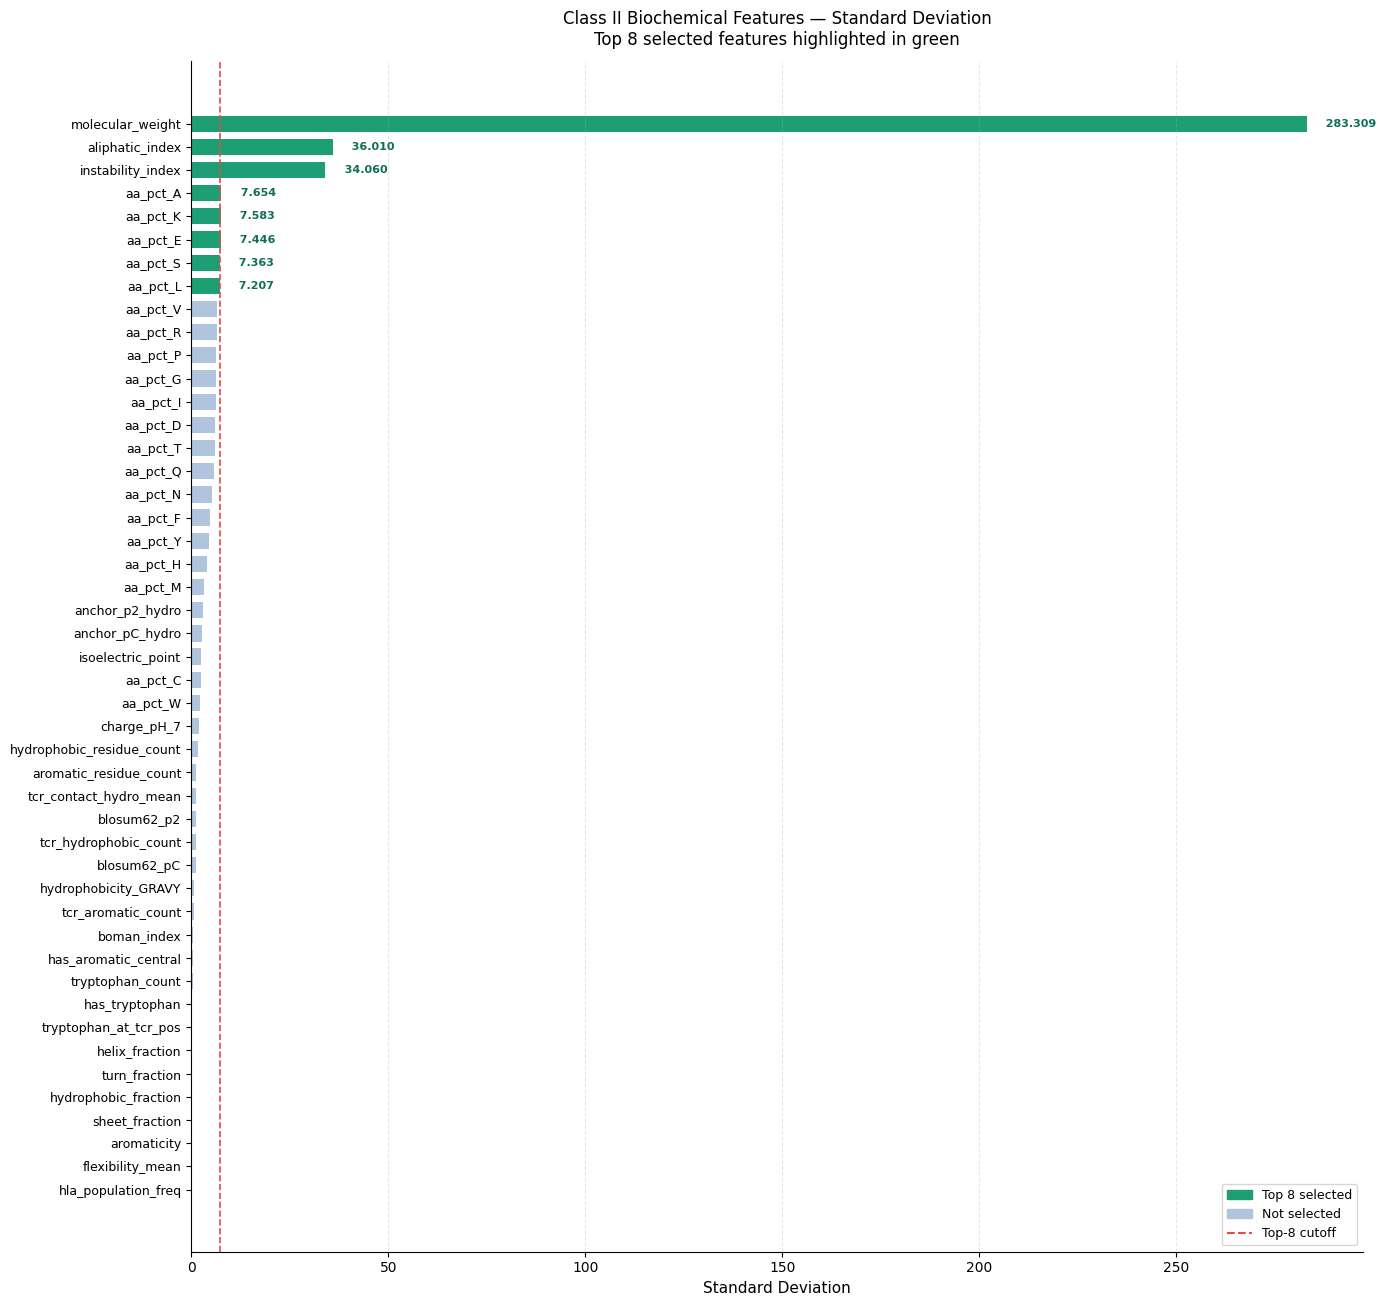

Plot saved → /Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/augmented/feature_sd_classII.png


In [10]:
fig, ax = plt.subplots(figsize=(14, max(6, len(sd_series) * 0.28)))

colors = ["#1D9E75" if f in top_features else "#B0C4DE" for f in sd_series.index]
ax.barh(range(len(sd_series)), sd_series.values, color=colors, edgecolor="none", height=0.7)
ax.set_yticks(range(len(sd_series)))
ax.set_yticklabels(sd_series.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Standard Deviation", fontsize=11)
ax.set_title(
    f"Class II Biochemical Features — Standard Deviation\n"
    f"Top {TOP_N_FEATURES_BY_SD} selected features highlighted in green",
    fontsize=12, pad=12
)
ax.axvline(
    sd_series.iloc[TOP_N_FEATURES_BY_SD - 1],
    color="#E24B4A", linestyle="--", linewidth=1.2
)
for i, feat in enumerate(sd_series.index):
    if feat in top_features:
        ax.text(
            sd_series[feat] + sd_series.max() * 0.01, i,
            f"  {sd_series[feat]:.3f}", va="center",
            fontsize=8, color="#0F6E56", fontweight="bold"
        )
top_patch  = mpatches.Patch(color="#1D9E75", label=f"Top {TOP_N_FEATURES_BY_SD} selected")
rest_patch = mpatches.Patch(color="#B0C4DE", label="Not selected")
cutoff_line = plt.Line2D([0],[0], color="#E24B4A", linestyle="--",
                         label=f"Top-{TOP_N_FEATURES_BY_SD} cutoff")
ax.legend(handles=[top_patch, rest_patch, cutoff_line], loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_PATH.parent / "feature_sd_classII.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved → {OUTPUT_PATH.parent / 'feature_sd_classII.png'}")